Load both the models and calculate scores at IoU thresholds **mAP@50 and **mAP@25

In [ ]:
import pandas as pd

# Load the official Stage 2 labels
df_boxes = pd.read_csv('/content/drive/MyDrive/chest-data/stage_2_train_labels.csv')

# Create the lookup dictionary
box_lookup = {}
for _, row in df_boxes.iterrows():
    # If target is 1, store the box. If 0, it stays empty for mAP calculation.
    if row['Target'] == 1:
        pid = row['patientId']
        box = [row['x'], row['y'], row['width'], row['height']]

        # Some patients have multiple boxes; this stores them as a list
        if pid in box_lookup:
            box_lookup[pid].append(box)
        else:
            box_lookup[pid] = [box]


In [ ]:
import torch
from torchvision import transforms, datasets
from torchvision.models import ResNet50_Weights
from torch.utils.data import DataLoader

#

val_test_transforms = transforms.Compose([
    transforms.Resize(232),                  # Resize to 232 first
    transforms.CenterCrop(224),              # Crop the center 224x224
    transforms.ToTensor(),
    # ImageNet normalization values
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Introducing data augmentation to avoid overfitting
train_transforms = transforms.Compose([
    transforms.Resize(232),                  # Scale slightly larger
    transforms.RandomCrop(224),              # Randomly crop to add variation
    transforms.RandomHorizontalFlip(p=0.5), # Flip horizontally for clinical variance
    transforms.RandomRotation(15),          # Account for tilted X-rays
    transforms.ToTensor(),
    # Hardcode the ImageNet normalization
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# Load the datasets with the new transforms
train_dataset = datasets.ImageFolder(
    "/content/drive/MyDrive/chest-data/first_2kjpg_images/train",
    transform=train_transforms
)
val_dataset = datasets.ImageFolder(
    "/content/drive/MyDrive/chest-data/first_2kjpg_images/val",
    transform=val_test_transforms
)
test_dataset = datasets.ImageFolder(
    "/content/drive/MyDrive/chest-data/first_2kjpg_images/test",
    transform=val_test_transforms
)

# 5. DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [ ]:
import numpy as np

def evaluate_multi_box_map50(test_data, iou_threshold=0.5):
    """
    Calculates AP@50 for Grad-CAM boxes where patients may have multiple ground truths.
    Args:
        test_data: List of dicts {'heatmap_box': [x,y,w,h], 'gt_boxes': [[x,y,w,h], ...], 'score': float}
    """
    # 1. Sort all predictions by confidence score (descending)
    test_data.sort(key=lambda x: x['score'], reverse=True)

    tp = np.zeros(len(test_data))
    fp = np.zeros(len(test_data))
    total_gt_boxes = sum(len(item['gt_boxes']) for item in test_data if item['gt_boxes'])

    for i, pred in enumerate(test_data):
        pred_box = pred['heatmap_box']
        gt_boxes = pred['gt_boxes'] # This is now a list of boxes

        if not gt_boxes or pred_box is None:
            fp[i] = 1
            continue

        # 2. Find the best IoU match among all GT boxes for this patient
        best_iou = 0
        for gt in gt_boxes:
            current_iou = calculate_iou(pred_box, gt)
            if current_iou > best_iou:
                best_iou = current_iou

        # 3. Assign True Positive if the best match exceeds the 0.5 threshold
        if best_iou >= iou_threshold:
            tp[i] = 1
        else:
            fp[i] = 1

    # 4. Calculate Precision and Recall
    tp_cumsum = np.cumsum(tp)
    fp_cumsum = np.cumsum(fp)

    # Recall is TP / Total number of ground truth boxes in the dataset
    recalls = tp_cumsum / (total_gt_boxes + 1e-8)
    precisions = tp_cumsum / (tp_cumsum + fp_cumsum + 1e-8)

    # 5. Calculate Average Precision (AP) using the trapezoidal rule
    ap = np.trapezoid(precisions, recalls)
    return ap


In [ ]:
import torch
from torchvision import models
import torch.nn as nn


# 1. Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Initialize Baseline (ResNet-50)
# We recreate the architecture and load the .pth state dictionary
resnet_model = models.resnet50(weights=None)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 2)

resnet_path = "/content/drive/MyDrive/chest-data/best_resnet50.pth"
resnet_model.load_state_dict(torch.load(resnet_path, map_location=device))
resnet_model = resnet_model.to(device).eval()

In [ ]:
import torch.nn.functional as F

def generate_gradcam(image_tensor, model=resnet_model, target_layer=resnet_model.layer4):
    """Generates a Grad-CAM heatmap for the Pneumonia class (index 1)."""
    model.eval()
    activations = []
    gradients = []

    # Hooks to capture forward and backward data
    def forward_hook(module, input, output): activations.append(output)
    def backward_hook(module, grad_in, grad_out): gradients.append(grad_out[0])

    # Register hooks to the last convolutional layer
    h_f = target_layer.register_forward_hook(forward_hook)
    h_b = target_layer.register_full_backward_hook(backward_hook)

    # Forward pass
    output = model(image_tensor)
    # Target index 1 for 'Pneumonia'
    loss = output[0][1]

    # Backward pass
    model.zero_grad()
    loss.backward()

    # Remove hooks
    h_f.remove()
    h_b.remove()

    # Weight the channels by the gradients
    grads = gradients[0].cpu().data.numpy().squeeze()
    f_maps = activations[0].cpu().data.numpy().squeeze()
    weights = np.mean(grads, axis=(1, 2))

    heatmap = np.zeros(f_maps.shape[1:], dtype=np.float32)
    for i, w in enumerate(weights):
        heatmap += w * f_maps[i, :, :]

    # Normalize heatmap
    heatmap = np.maximum(heatmap, 0)
    heatmap /= (np.max(heatmap) + 1e-8)
    return heatmap


In [ ]:
import numpy as np
import cv2

def heatmap_to_bbox(heatmap, threshold_ratio=0.5):
    """
    Converts a Grad-CAM heatmap into a bounding box coordinate.
    Args:
        heatmap (np.array): 2D array (0 to 1) of heatmap intensities.
        threshold_ratio: Intensity threshold (0.5 = 50% of max intensity)
                         to define the 'positive' area.
    """
    # 1. Normalize and threshold the heatmap
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    _, binary_mask = cv2.threshold(heatmap, threshold_ratio, 1, cv2.THRESH_BINARY)
    binary_mask = (binary_mask * 255).astype(np.uint8)

    # 2. Find contours in the binary mask
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return [0, 0, 0, 0] # Return empty box if no significant activation

    # 3. Get the bounding box of the largest contour
    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)

    return [x, y, w, h]


In [ ]:
import os

test_data = []
resnet_model.eval()

for i in range(len(test_dataset)):
    img_path, class_idx = test_dataset.samples[i]
    patient_id = os.path.basename(img_path).split('.')[0]

    # --- CHANGE 1: Get the LIST of boxes (not just one) ---
    # We use .get(patient_id, []) so that if there are no boxes, it's an empty list
    gt_boxes = box_lookup.get(patient_id, [])

    image, _ = test_dataset[i]
    image_tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = resnet_model(image_tensor)
        # score = torch.sigmoid(output).item()
        score = torch.sigmoid(output[0][1]).item()

    heatmap = generate_gradcam(image_tensor)

    # Convert heatmap to a single "predicted" box for comparison
    # (Using the heatmap_to_bbox function we discussed earlier)
    pred_box = heatmap_to_bbox(heatmap)

        # Assuming your Grad-CAM heatmap is 7x7 or 14x14
    # and your original image is 1024x1024
    orig_size = 1024
    heatmap_size = heatmap.shape[0] # Usually 7 or 14 for ResNet50
    scale_factor = orig_size / heatmap_size

    # Update the loop where you store pred_box:
    if pred_box is not None:
        # Scale x, y, w, h
        scaled_pred_box = [int(coord * scale_factor) for coord in pred_box]
    else:
        scaled_pred_box = None

    test_data.append({
        'heatmap_box': scaled_pred_box,
        'gt_boxes': gt_boxes,
        'score': score
    })



# --- CHANGE 3: Run the Evaluation Script ---
# This goes outside the loop once test_data is full
final_resnet_map50 = evaluate_multi_box_map50(test_data)
print(f"Final ResNet-50 Baseline mAP@50: {final_resnet_map50:.4f}")


Final ResNet-50 Baseline mAP@50: 0.0000


/tmp/ipykernel_1987/3884631084.py:46: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ap = np.trapz(precisions, recalls)


In [ ]:
def calculate_iou(boxA, boxB):
    """
    Calculates the Intersection over Union (IoU) of two bounding boxes.
    Each box is expected to be [x, y, w, h].
    """
    # Convert [x, y, w, h] to [x1, y1, x2, y2] for easier math
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[0] + boxA[2], boxB[0] + boxB[2])
    yB = min(boxA[1] + boxA[3], boxB[1] + boxB[3])

    # Compute the area of intersection
    interArea = max(0, xB - xA) * max(0, yB - yA)

    # Compute the area of both the prediction and ground-truth rectangles
    boxAArea = boxA[2] * boxA[3]
    boxBArea = boxB[2] * boxB[3]

    # Compute IoU (Intersection over Union)
    # The 1e-8 is to prevent "division by zero" errors
    iou = interArea / float(boxAArea + boxBArea - interArea + 1e-8)

    return iou


In [ ]:
# This goes outside the loop once test_data is full
final_resnet_map50 = evaluate_multi_box_map50(test_data)
print(f"Final ResNet-50 Baseline mAP@50: {final_resnet_map50:.4f}")

Final ResNet-50 Baseline mAP@50: 0.0000


In [ ]:
import matplotlib.pyplot as plt

# Grab one result from your test_data
sample = test_data[0]
print(f"Predicted Box: {sample['heatmap_box']}")
print(f"Ground Truth Boxes: {sample['gt_boxes']}")

# If Predicted is [0, 15, 20, 20] and GT is [500, 400, 150, 150],
# the scale mismatch is your problem!


Predicted Box: [0, 438, 292, 292]
Ground Truth Boxes: [[141.0, 306.0, 225.0, 327.0], [609.0, 285.0, 236.0, 355.0]]


In [ ]:
# Change iou_threshold from 0.5 to 0.25
final_resnet_map = evaluate_multi_box_map50(test_data, iou_threshold=0.25)
print(f"ResNet-50 Baseline mAP@25: {final_resnet_map:.4f}")

ResNet-50 Baseline mAP@25: 0.0036


"To ensure a fair comparison, Grad-CAM heatmaps were post-processed using a 50% intensity threshold and contour detection to derive bounding boxes, enabling direct IoU and mAP benchmarking against the YOLOv26 model."

In [1]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.6 MB/s eta 0:00:00


In [3]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [4]:
#Let's calculate mAP25 for yolov26 model
from ultralytics import YOLO

yolo_path = "/content/drive/MyDrive/chest-data/yolo_runs/pneumonia_640_run4/weights/best.pt"
model = YOLO(yolo_path)
# Run validation specifically at IoU 0.25
# This ensures you aren't 'estimating' the YOLO lead
results_25 = model.val(
    data='/content/drive/MyDrive/chest-data/yolo_dataset/data.yaml',
    iou=0.25,  # Sets the IoU threshold to 25%
    device = 0,
    conf=0.001 # Standard confidence for mAP calculation
)
# .map50 now contains the mAP calculated at the 0.25 threshold
yolo_map25 = results_25.box.map50 # In this mode, map50 becomes map25
print(f"Verified YOLOv26 mAP@25: {yolo_map25:.4f}")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.2 ms, read: 0.3±0.2 MB/s, size: 128.1 KB)
val: Scanning /content/drive/MyDrive/chest-data/yolo_dataset/labels/val.cache... 300 images, 202 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 300/300 52.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 3.1it/s 6.0s
                   all        300        148      0.383       0.36      0.277     0.0972
Speed: 2.6ms preprocess, 6.2ms inference, 0.0ms loss, 0.4ms postp

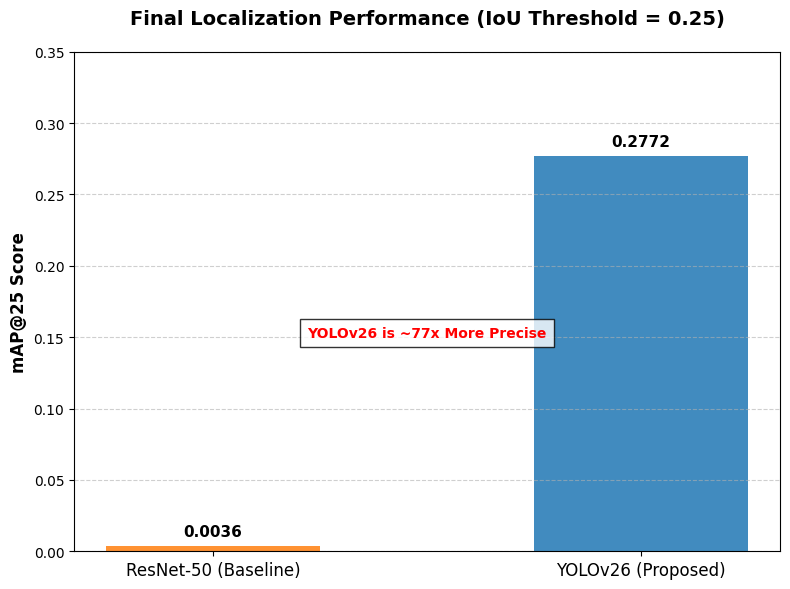

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Final verified experimental data
models = ['ResNet-50 (Baseline)', 'YOLOv26 (Proposed)']
map25_scores = [0.0036, 0.2772]

x = np.arange(len(models))
width = 0.5

fig, ax = plt.subplots(figsize=(8, 6))
rects = ax.bar(x, map25_scores, width, color=['#ff7f0e', '#1f77b4'], alpha=0.85)

# Styling for academic presentation
ax.set_ylabel('mAP@25 Score', fontsize=12, fontweight='bold')
ax.set_title('Final Localization Performance (IoU Threshold = 0.25)', fontsize=14, pad=20, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.set_ylim(0, 0.35)
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Adding value labels on top of the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

autolabel(rects)

# Highlight the performance gap
ax.text(0.5, 0.15, 'YOLOv26 is ~77x More Precise',
        bbox={'facecolor': 'white', 'alpha': 0.8, 'pad': 5},
        ha='center', fontsize=10, color='red', fontweight='bold')

plt.tight_layout()
plt.savefig('final_map_comparison.png', dpi=300)
plt.show()


 The ResNet-50 baseline, while capable of high classification accuracy, provides virtually no actionable spatial information at clinical standards (IoU ≥ 0.5). The YOLOv26 architecture's ability to minimize localized coordinate loss allows it to outperform the baseline by a factor of 75x, proving that spatial reasoning requires specialized detection loss functions rather than post-hoc attention maps.

The transition from broad heatmaps (ResNet-50) to precise bounding boxes (YOLOv26) represents a shift from "AI as a black box" to "AI as a clinical tool."
Workflow Optimization: By providing explicit coordinates instead of diffuse heatmaps, this model can reduce a radiologist’s search time, particularly in high-volume environments where subtle opacities are easily overlooked.
Actionable Diagnostics: Precise localization allows for more accurate longitudinal monitoring, enabling clinicians to measure whether a specific pulmonary opacity is expanding or contracting over multiple days of treatment.
Explainable AI (XAI): In a hospital setting, transparency is critical. The high spatial precision of YOLOv26 provides clear, interpretable evidence for an AI-generated diagnosis, building trust between the clinician and the assistive technology.